# KND_04 — Notebook 8: Test our final model

**Main question:** How well does our chosen model work on later records that we did not use to choose it?

We use the **Random Forest saved in Notebook 7**, with the same **0.20 alert cutoff**. We do not train again or try different cutoffs here.

**Target:** `long_stay_30` — **1** means more than 30 days; **0** means 30 days or less.

## How to start

1. Open this notebook in Colab.
2. Upload **KND_04_Step8_Input_Files.zip** in the Files panel.
3. Select **Runtime → Run all**.
4. Download **KND_04_Step8_Results.zip** at the end.

The ZIP contains the exact model from our checked Notebook 7 run. You do not need to rerun earlier notebooks. Do not mix it with a different local model.

**If the library check stops:** copy the `%pip install ...` command it prints into a new cell, run it, select **Runtime → Restart session**, then Run all again. Saved models need the same library versions used to build them.

Each main cell has one job. The longer file checks are in **step8_helpers.py**, included in the ZIP. That file checks inputs and saves results; it does not train a model. The prediction and scoring steps are visible below.

**Say this in the viva:** “Training teaches the model. Validation helps us choose the model and cutoff. Testing is our final check after those choices are fixed.”

## 1. Open the input ZIP — setup only

This opens our files. It does not change the data or model.

**Say this:** “We loaded the matching files saved from our earlier work.”

In [1]:
from pathlib import Path
from zipfile import ZipFile
import json, sys

locations = [Path.cwd(), Path.cwd() / "outputs", Path("/content")]
zip_path = next((p / "KND_04_Step8_Input_Files.zip" for p in locations
                 if (p / "KND_04_Step8_Input_Files.zip").is_file()), None)
if zip_path is not None:
    with ZipFile(zip_path) as archive:
        names = archive.namelist()
        assert len(names) == len(set(names)) == 12
        assert all(len(Path(n).parts) == 2 and Path(n).parts[0] == "step8_inputs" and ".." not in Path(n).parts for n in names)
        archive.extractall(zip_path.parent)
INPUT_DIR = next((p / "step8_inputs" for p in locations
                  if (p / "step8_inputs/input_manifest.json").is_file()), None)
if INPUT_DIR is None:
    raise FileNotFoundError("Upload KND_04_Step8_Input_Files.zip, then rerun this cell.")
INPUT_DIR = INPUT_DIR.resolve()
sys.path.insert(0, str(INPUT_DIR))
print("Input folder:", INPUT_DIR)

Input folder: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step8_inputs


## 2. Check the files and libraries — setup only

The helper checks that the files belong together and the software can load our saved model. Stop and fix any message here; do not remove the checks.

**Say this:** “We checked that we were using the correct saved model and files.”

In [2]:
import importlib
sys.modules.pop("step8_helpers", None)
importlib.invalidate_caches()
import step8_helpers as helper
helper.check_libraries(INPUT_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, average_precision_score, roc_auc_score, brier_score_loss)

RESULTS_DIR = INPUT_DIR.parent / "step8_results"
RESULTS_DIR.mkdir(exist_ok=True)

File and library checks passed.


## 3. Load the model and its saved cutoff

The model already includes our preprocessing rules. Missing ages, categories and scaling use what was learned from training data.

**Say this:** “We loaded the trained model. We kept the same preprocessing and the same cutoff chosen in Notebook 7.”

In [3]:
model, policy = helper.load_saved_model(INPUT_DIR)
threshold = policy["alert_threshold"]
model_state_before = joblib.hash(model)

print("Model:", policy["candidate"]["family"])
print("Alert cutoff:", threshold)
print("Training records used earlier:", policy["fit_rows"])
print("No training happens in this notebook.")

Model: random_forest
Alert cutoff: 0.2
Training records used earlier: 6096
No training happens in this notebook.


## 4. Load the test inputs and the correct answers

**X_test** contains the 10 arrival fields. **y_test** contains the correct 0/1 answers. We keep the answers out of the model inputs.

These are **1,672 admissions from 1 January to 14 August 2026**. The file check also confirms that these animals are absent from the earlier training and validation groups. One row is one admission; an animal can have separate visits within the same group.

**Say this:** “We used later records for testing. The model saw only the arrival details, not the correct answers.”

In [4]:
X_test, answers = helper.load_test_data(INPUT_DIR, policy)
y_test = answers["long_stay_30"].to_numpy()
reference = json.loads((INPUT_DIR / "reference_results.json").read_text())

print("Test records:", len(X_test))
print("Actual long stays:", int(y_test.sum()))
print("Actual short stays:", int((y_test == 0).sum()))
print("Arrival dates:", answers.intake_date.min(), "to", answers.intake_date.max())

Row order, dates, answers and animal separation checked.
Test records: 1672
Actual long stays: 314
Actual short stays: 1358
Arrival dates: 2026-01-01 to 2026-08-14


## 5. Make predictions

The model gives a long-stay score for each admission. A score **at or above 0.20** becomes a long-stay alert.

Example: **0.35 → alert**, **0.10 → no alert**. The cutoff is copied from Notebook 7; we do not change it after seeing the test answers. These scores have not been shown to be reliable probabilities.

**Say this:** “We asked the saved model to predict the test records and used the saved cutoff to decide which ones to flag.”

In [5]:
test_scores = model.predict_proba(X_test)[:, 1]
test_predictions = (test_scores >= threshold).astype(int)

print("Long-stay alerts:", int(test_predictions.sum()))
print("Share of arrivals flagged:", f"{test_predictions.mean():.1%}")
print("The model and cutoff are unchanged.")

Long-stay alerts: 962
Share of arrivals flagged: 57.5%
The model and cutoff are unchanged.


## 6. Count correct predictions and mistakes

The **confusion matrix** is a count of four outcomes:

- **TN:** actual short stay, correctly predicted short.
- **FP:** actual short stay, wrongly flagged long — a **false alert**.
- **FN:** actual long stay, wrongly predicted short — a **missed long stay**.
- **TP:** actual long stay, correctly flagged long.

**Say this:** “We counted how many long stays we caught, how many we missed, and how many false alerts we raised.”

In [6]:
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()

print("Correct short stays:", tn)
print("False alerts:", fp)
print("Missed long stays:", fn)
print("Caught long stays:", tp)
assert tn + fp + fn + tp == len(y_test)

Correct short stays: 626
False alerts: 732
Missed long stays: 84
Caught long stays: 230


## 7. Calculate the scores

- **Precision:** Of our alerts, how many were right? `TP / (TP + FP)`
- **Recall:** Of the actual long stays, how many did we catch? `TP / (TP + FN)`
- **Accuracy:** Of all predictions, how many were right?
- **F1:** combines precision and recall. **F2** gives more importance to recall.
- **Average precision (AP):** checks whether real long stays tend to get higher scores. Higher is better; this is our main ranking measure.
- **Balanced accuracy:** gives equal importance to recognising each class.
- **ROC-AUC:** another check of how scores rank the two classes.
- **Brier error:** checks errors in probability scores. Lower is better; it does not prove calibration by itself.
- **Alert share:** the share of all admissions we flag — useful for understanding workload.

The function below lets us calculate the same scores for our model and the baseline.

**Say this:** “We used several scores because accuracy alone can hide missed long stays. Precision and recall show the trade-off more clearly.”

In [7]:
def measure(actual, scores, predicted):
    return pd.Series({
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "F1": f1_score(actual, predicted, zero_division=0),
        "F2": fbeta_score(actual, predicted, beta=2, zero_division=0),
        "Accuracy": accuracy_score(actual, predicted),
        "Balanced accuracy": balanced_accuracy_score(actual, predicted),
        "Average precision": average_precision_score(actual, scores),
        "ROC-AUC": roc_auc_score(actual, scores),
        "Brier error": brier_score_loss(actual, scores),
        "Alert share": np.mean(predicted)
    })

In [8]:
test_metrics = measure(y_test, test_scores, test_predictions)
test_metrics.name = "Our model"
print(test_metrics.round(4).to_string())

Precision            0.2391
Recall               0.7325
F1                   0.3605
F2                   0.5185
Accuracy             0.5120
Balanced accuracy    0.5967
Average precision    0.3151
ROC-AUC              0.6504
Brier error          0.1531
Alert share          0.5754


## 8. Compare with a simple baseline

The baseline always predicts **short stay**. Its score is the long-stay share from the **training** data, not a number learned from the test answers.

It may have good accuracy because many stays are short. But it catches **zero long stays**. We also compare AP and Brier error so we do not make our model look better by showing only one measure.

**Say this:** “We compared our model with predicting short stays for everyone. That helps show what the model adds and what it still gets wrong.”

In [9]:
training_rate = reference["training_long_share"]
baseline_scores = np.full(len(y_test), training_rate)
baseline_predictions = np.zeros(len(y_test), dtype=int)
baseline_metrics = measure(y_test, baseline_scores, baseline_predictions)
baseline_metrics.name = "Always-short baseline"

summary = pd.concat([test_metrics, baseline_metrics], axis=1)
print(summary.round(4).to_string())
assert baseline_metrics["Recall"] == 0

                   Our model  Always-short baseline
Precision             0.2391                 0.0000
Recall                0.7325                 0.0000
F1                    0.3605                 0.0000
F2                    0.5185                 0.0000
Accuracy              0.5120                 0.8122
Balanced accuracy     0.5967                 0.5000
Average precision     0.3151                 0.1878
ROC-AUC               0.6504                 0.5000
Brier error           0.1531                 0.1684
Alert share           0.5754                 0.0000


## 9. Compare validation and test results

This compares the **same model and same cutoff** on two different periods. It is not another model selection step.

The share of long stays can change over time. That can affect precision and AP, so a score difference does not prove the model has become better or worse by itself.

**Say this:** “We compared the validation and test results to see how the fixed model performed in a later period. We did not use this comparison to change it.”

In [10]:
saved = reference["validation_metrics"]
validation_metrics = pd.Series({
    "Precision": saved["precision"], "Recall": saved["recall"],
    "F1": saved["f1"], "F2": saved["f2"], "Accuracy": saved["accuracy"],
    "Balanced accuracy": saved["balanced_accuracy"],
    "Average precision": saved["average_precision"], "ROC-AUC": saved["roc_auc"],
    "Brier error": saved["brier_score"], "Alert share": saved["alert_fraction"]
})
comparison = pd.DataFrame({"Validation": validation_metrics, "Test": test_metrics})
print(comparison.round(4).to_string())
print("Validation long-stay share:", f"{reference['validation_long_share']:.1%}")
print("Test long-stay share:", f"{y_test.mean():.1%}")

                   Validation    Test
Precision              0.2678  0.2391
Recall                 0.9061  0.7325
F1                     0.4134  0.3605
F2                     0.6136  0.5185
Accuracy               0.4583  0.5120
Balanced accuracy      0.6225  0.5967
Average precision      0.3585  0.3151
ROC-AUC                0.7050  0.6504
Brier error            0.1780  0.1531
Alert share            0.7128  0.5754
Validation long-stay share: 21.1%
Test long-stay share: 18.8%


## 10. Show the mistake counts as a picture

Rows show the actual answer. Columns show the prediction. The two diagonal boxes are correct predictions.

**Say this:** “This picture shows the same four counts we calculated earlier.”

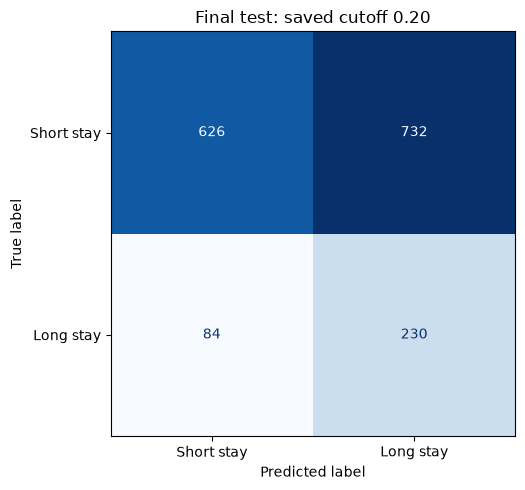

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, labels=[0, 1],
    display_labels=["Short stay", "Long stay"],
    cmap="Blues", colorbar=False, ax=ax)
ax.set_title(f"Final test: saved cutoff {threshold:.2f}")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "01_test_confusion_matrix.png", dpi=150)
plt.show()

## 11. Show the main score comparison

Here, higher bars are better. Brier error is left out of this chart because its direction is different: lower is better.

**Say this:** “The chart helps us compare catching long stays, correct alerts and overall accuracy with the baseline.”

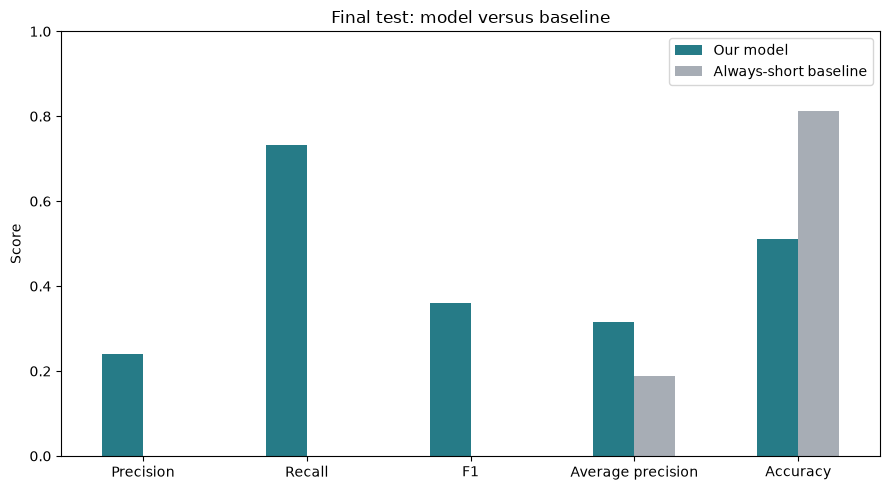

In [12]:
main_scores = ["Precision", "Recall", "F1", "Average precision", "Accuracy"]
ax = summary.loc[main_scores].plot.bar(figsize=(9, 5), color=["#267b87", "#a7adb5"])
ax.set(title="Final test: model versus baseline", ylabel="Score", ylim=(0, 1))
ax.tick_params(axis="x", rotation=0)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "02_test_score_comparison.png", dpi=150)
plt.show()

## 12. Keep a record of every prediction and mistake

We save all predictions and all wrong predictions. The six mistakes shown here are simply the first six in the file, not selected examples that make results look good or bad. A wrong prediction does not explain its cause.

**Say this:** “We saved every prediction so we can check the results. We also saved all mistakes separately for reporting.”

In [13]:
predictions = answers[["source_row_number", "id", "intake_date", "long_stay_30"]].copy()
predictions["long_stay_score"] = test_scores
predictions["predicted_long_stay"] = test_predictions
predictions["correct"] = test_predictions == y_test

mistakes = predictions.loc[~predictions["correct"]]
print("Total wrong predictions:", len(mistakes))
print(mistakes.head(6).round(4).to_string(index=False))
assert len(mistakes) == fp + fn

Total wrong predictions: 816
 source_row_number      id intake_date  long_stay_30  long_stay_score  predicted_long_stay  correct
              8019 A378360  2026-01-01             0           0.5438                    1    False
              8020 A439048  2026-01-01             0           0.4137                    1    False
              8021 A439049  2026-01-01             0           0.3055                    1    False
              8022 A366720  2026-01-02             0           0.3271                    1    False
              8023 A430949  2026-01-02             0           0.4827                    1    False
              8025 A439055  2026-01-02             0           0.2487                    1    False


## 13. Read the short viva script

The text below uses your actual results. It divides the explanation among four members. Everyone should understand the full workflow; only claim the work each person really did.

In [14]:
viva_text = helper.create_viva_text(
    policy, answers, test_metrics, baseline_metrics, (tn, fp, fn, tp))
print(viva_text)

KND_04 - Notebook 8: final test evaluation

Member 1 - What we tested
"We used the Random Forest model saved in Notebook 7. We kept its alert cutoff
at 0.20. We tested it on 1,672 later admissions, from 1 January to
14 August 2026. We did not train the model or change the cutoff here."

Member 2 - Predictions and mistakes
"Our target is whether an animal stays more than 30 days. One means a long
stay, and zero means 30 days or less. We caught 230 long stays and missed
84. We also raised 732 false alerts. There were 626 correctly predicted
short stays. A false alert means we flagged a long stay, but it was short."

Member 3 - What the scores mean
"Recall was 73.2%. That is the share of actual long stays we caught.
Precision was 23.9%. That is the share of our alerts that were right.
We flagged 57.5% of all arrivals. Our average precision was
0.3151, compared with 0.1878 for the constant-score baseline.
Accuracy alone is not enough because predicting short stays for everyone
can look acc

## 14. Save and download the results

The final check confirms that the model and original input files stayed unchanged. The results folder contains:

- **test_metrics.csv:** model and baseline scores.
- **confusion_matrix.csv:** the four prediction counts.
- **test_predictions.csv:** every test answer, score and prediction.
- **test_mistakes.csv:** every wrong prediction.
- **validation_vs_test.csv:** the two periods compared.
- **viva_summary.txt:** the four-member speaking guide.
- **final_test_notes.json:** dates, settings, checks and limitations.
- Two charts and copies of the saved decision rule and evaluation plan.

In Colab, refresh the Files panel, right-click **KND_04_Step8_Results.zip**, and choose **Download**. Keep it so the results survive a runtime reset.

In [15]:
results_zip = helper.save_results(
    INPUT_DIR, RESULTS_DIR, model, policy, model_state_before,
    predictions, summary, comparison, (tn, fp, fn, tp), viva_text)
print("Final test evaluation is complete.")

Checks passed: original files and model are unchanged.
Results folder: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step8_results
Download: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\KND_04_Step8_Results.zip
Final test evaluation is complete.


## What we can honestly say

“We tested the fixed model on later records and reported its results, including missed long stays and false alerts.”

We cannot yet say it is ready for real shelter decisions. A high alert share means more work for staff. We have not agreed those costs with a shelter or shown that the system improves outcomes.

The data comes from **Sonoma County, California, USA**. The results do not automatically apply to Sri Lanka. Blank outcomes were assumed to be ongoing stays during target creation, and the original snapshot cannot prove when every attribute was entered or updated. Scores have not been probability-calibrated.

**The test set has now been evaluated.** Rerunning the same fixed notebook is a reproducibility check, not a fresh independent test. If we change the model based on these test answers, we need new independent data to assess the changed model fairly. The copied Notebook 7 policy describes its earlier pre-test status; `final_test_notes.json` records this completed test.

## Quick viva questions

**Did you train in Notebook 8?** “No. We loaded the model saved in Notebook 7.”

**Why did you keep 0.20?** “It was chosen using validation data. Changing it using test answers would make the test part of model development.”

**Why is accuracy not enough?** “Predicting short stays for everyone can look accurate while missing every long stay.”

**What is a false alert?** “We predicted a long stay, but the actual stay was short.”

**What is a missed long stay?** “The actual stay was long, but we predicted short.”

**Did you fill missing test ages using the test median?** “No. The saved pipeline uses the age values learned from training.”

**Is a score of 0.60 definitely a 60% chance?** “No. We have not shown that the scores are reliable probabilities.”

## What comes after this?

This completes the final evaluation of this selected model. The remaining project work includes explaining model behaviour, any separate data-mining requirements, the user interface, report and presentation. We should review those against the assignment before choosing the next notebook.

References: [official dataset](https://data.sonomacounty.ca.gov/Government/Animal-Shelter-Intake-and-Outcome/924a-vesw), [loading saved models with matching libraries](https://scikit-learn.org/stable/model_persistence.html), [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html).